# Strategy Risk

## Overview

This notebook demonstrates the public functions in `strategy_risk` using compact binary-outcome strategy examples.
- Problem: a strategy can appear attractive while depending on a precision rate that is too fragile to maintain.
- Approach: estimate the precision threshold required by the target Sharpe ratio from the average winning outcome, average losing outcome, and betting frequency, then measure the probability that realized precision falls below that threshold.
- Implied Precision: It computes the minimum precision required for a target annualized Sharpe ratio.
- Implied Frequency: It computes the number of yearly bets required for a target annualized Sharpe ratio.
- Probability of Strategy Failure: It estimates the probability that realized precision falls below the target-implied precision.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

In [2]:
from src.model_backtesting.strategy_risk import (
    implied_betting_frequency,
    implied_precision,
    mix_gaussians,
    probability_of_strategy_failure,
)

## Strategy Assumptions

This cell defines the binary-outcome assumptions used for the strategy-risk examples.
- `stop_loss` is the average outcome when the bet loses.
- `profit_taking` is the average outcome when the bet wins.
- `frequency` is the number of bets taken per year.
- `precision` is the probability that a bet has a positive outcome.
- `target_sharpe` is the annualized Sharpe ratio that separates success from failure.

In [3]:
stop_loss = -0.01
profit_taking = 0.005
frequency = 260
precision = 0.72
target_sharpe = 2.0

## Implied Precision

This cell computes the minimum precision required to reach the target Sharpe ratio.
- The result is the break-even hit rate for the selected payoff shape and yearly opportunity count.
- If realized precision falls below this value, the strategy is not expected to reach the target.

In [4]:
threshold_precision = implied_precision(
    stop_loss=stop_loss,
    profit_taking=profit_taking,
    frequency=frequency,
    target_sharpe=target_sharpe,
)

print(f"Required precision: {threshold_precision:.2%}")

Required precision: 72.22%


This cell plots the implied precision surface.
- The x-axis varies frequency.
- The y-axis varies the average losing outcome while keeping the average winning outcome fixed.
- Required precision generally falls as frequency increases, because more bets can compound a smaller edge.
- Required precision rises as the average losing outcome becomes more negative, because each losing bet needs to be offset by a higher win rate.

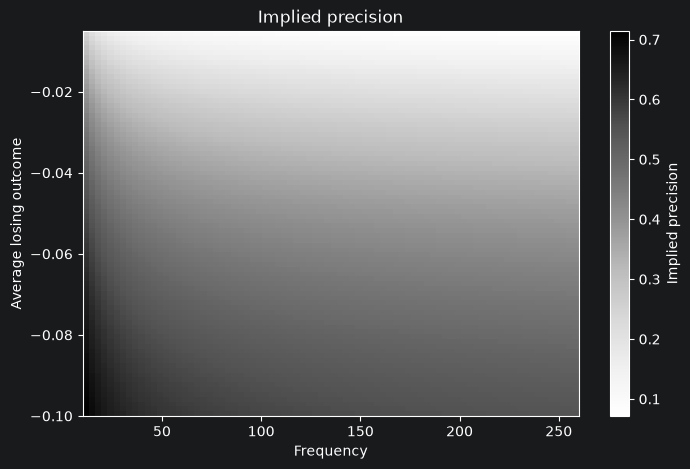

In [5]:
frequencies = np.linspace(10, 260, 80)
stop_losses = np.linspace(-0.10, -0.005, 80)
profit_taking_grid = 0.10
target_sharpe_grid = 1.5

frequency_grid, stop_loss_grid = np.meshgrid(frequencies, stop_losses)
precision_surface = implied_precision(
    stop_loss=stop_loss_grid,
    profit_taking=profit_taking_grid,
    frequency=frequency_grid,
    target_sharpe=target_sharpe_grid,
)

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(
    precision_surface,
    origin="lower",
    aspect="auto",
    cmap="Greys",
    extent=[frequencies.min(), frequencies.max(), stop_losses.min(), stop_losses.max()],
)
fig.colorbar(image, ax=ax, label="Implied precision")
ax.set_title("Implied precision")
ax.set_xlabel("Frequency")
ax.set_ylabel("Average losing outcome")
plt.show()

## Implied Frequency

This cell computes the yearly betting frequency required to reach the target Sharpe ratio.
- The result is the opportunity count needed for the selected payoff shape and precision rate.
- If the strategy cannot generate this many bets, it is not expected to reach the target.

In [6]:
required_frequency = implied_betting_frequency(
    stop_loss=stop_loss,
    profit_taking=profit_taking,
    precision=precision,
    target_sharpe=target_sharpe,
)

print(f"Required bets per year: {required_frequency:.1f}")

Required bets per year: 283.5


This cell plots the implied betting-frequency surface.
- The x-axis varies precision.
- The y-axis varies the average losing outcome while keeping the average winning outcome fixed.
- Required frequency falls as precision moves farther above breakeven, because each bet contributes more expected return.
- Required frequency rises as the average losing outcome becomes more negative, especially when precision is close to the breakeven region.

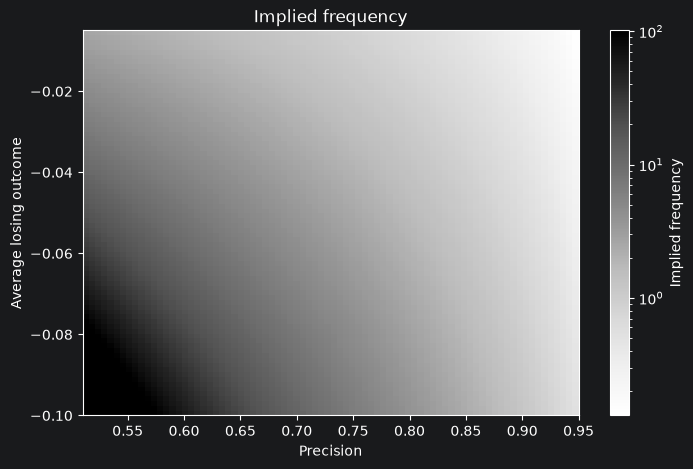

In [11]:
precisions = np.linspace(0.51, 0.95, 80)
precision_grid, stop_loss_grid = np.meshgrid(precisions, stop_losses)
frequency_surface = implied_betting_frequency(
    stop_loss=stop_loss_grid,
    profit_taking=profit_taking_grid,
    precision=precision_grid,
    target_sharpe=target_sharpe_grid,
)
frequency_vmax = np.nanpercentile(frequency_surface, 98)

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(
    frequency_surface,
    origin="lower",
    aspect="auto",
    cmap="Greys",
    norm=LogNorm(vmin=np.nanmin(frequency_surface), vmax=frequency_vmax),
    extent=[precisions.min(), precisions.max(), stop_losses.min(), stop_losses.max()],
)
fig.colorbar(image, ax=ax, label="Implied frequency")
ax.set_title("Implied frequency")
ax.set_xlabel("Precision")
ax.set_ylabel("Average losing outcome")
plt.show()

## Probability of Strategy Failure

This cell creates a compact return sample from a two-component mixture.
- The positive component represents winning bets.
- The negative component represents losing bets.
- The generated sample is used as observed bet outcomes.

In [8]:
returns = mix_gaussians(
    mean_1=0.05,
    mean_2=-0.10,
    sigma_1=0.05,
    sigma_2=0.10,
    probability_1=0.75,
    num_observations=2600,
    random_state=42,
)

print(f"Average winning outcome: {returns[returns > 0].mean():.4f}")
print(f"Average losing outcome: {returns[returns <= 0].mean():.4f}")
print(f"Observed precision: {(returns > 0).mean():.2%}")

Average winning outcome: 0.0633
Average losing outcome: -0.0864
Observed precision: 65.23%


This cell estimates the probability that the strategy fails to reach the target Sharpe ratio.
- The function first derives the target-implied precision threshold.
- It then estimates the probability that precision falls below that threshold.

In [9]:
failure_probability = probability_of_strategy_failure(
    returns=returns,
    frequency=frequency,
    target_sharpe=target_sharpe,
)

print(f"Probability of strategy failure: {failure_probability:.2%}")

Probability of strategy failure: 47.28%
